ELE8100- CyberAI

Coursework 1: AI-Based Cybersecurity

Name - Chandana Saligrama Perumal
Student ID - 40496637

INTRODUCTION:

This developement of this coursework represents the design and implementation of AI-based  facial recognition system called "FaceGuard", developed for secure access control to a server room. The system should recognise 40 employees from grayscale 64*64 facial images and restrict access exclusively to three authorised personnel (IDs 0,5 and 10).

The solution consists of three components:
1. CNN Architecture Design
2. Model Training and Evaluation
3. Access Control Decision Function

The following sections justify the design decisions and analyse results is alignement with the coursework requirements. 


1. IMPORTS

In [30]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import kagglehub


2. LOAD DATA

In [31]:
# Download dataset
path = kagglehub.dataset_download(
    "martininf1n1ty/olivetti-faces-augmented-dataset"
)

images = np.load(r"C:\Users\Dhanyashree K\Documents\pinky\augmented_faces.npy")
labels = np.load(r"C:\Users\Dhanyashree K\Documents\pinky\augmented_labels.npy")


# Reshape and normalize
images = images.reshape(-1, 64, 64).astype(np.float32)
images = images / 255.0
images = np.expand_dims(images, axis=1)  # (N,1,64,64)

# Train-test split
train_images, test_images, train_labels, test_labels = train_test_split(
    images, labels, test_size=0.2, random_state=42, stratify=labels
)

# Convert to tensors
train_images = torch.tensor(train_images)
train_labels = torch.tensor(train_labels, dtype=torch.long)
test_images = torch.tensor(test_images)
test_labels = torch.tensor(test_labels, dtype=torch.long)

train_dataset = TensorDataset(train_images, train_labels)
test_dataset = TensorDataset(test_images, test_labels)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)


The model is trained using CrossEntropyloss, it is suitable for multi-class classification problems. The Adam optimiser is used to update the model weights efficiently. To improve the final accuracy a learning rate scheduler is applied to gradually reduce the learning rate. Both accuracy and loss were monitored to evaluate learning performance during the training process.

3. IMPROVED CNN ARCHITECTURE

In [32]:
class FaceGuardCNN(nn.Module):
    def __init__(self):
        super(FaceGuardCNN, self).__init__()

        self.features = nn.Sequential(
            
            # Block 1
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 64 -> 32
            
            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 32 -> 16
            
            # Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 16 -> 8
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 40)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


4. TRAINING SETUP

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FaceGuardCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.0005)

# Learning rate scheduler (improves final accuracy)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

num_epochs = 30


5. TRAINING LOOP

In [34]:
train_losses = []
test_losses = []
train_acc = []
test_acc = []

for epoch in range(num_epochs):

    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images_batch, labels_batch in train_loader:
        images_batch, labels_batch = images_batch.to(device), labels_batch.to(device)

        optimizer.zero_grad()

        outputs = model(images_batch)
        loss = criterion(outputs, labels_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels_batch.size(0)
        correct += (predicted == labels_batch).sum().item()

    train_losses.append(running_loss / len(train_loader))
    train_acc.append(100 * correct / total)

    # Evaluation
    model.eval()
    correct = 0
    total = 0
    test_loss = 0

    with torch.no_grad():
        for images_batch, labels_batch in test_loader:
            images_batch, labels_batch = images_batch.to(device), labels_batch.to(device)

            outputs = model(images_batch)
            loss = criterion(outputs, labels_batch)

            test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels_batch.size(0)
            correct += (predicted == labels_batch).sum().item()

    test_losses.append(test_loss / len(test_loader))
    test_acc.append(100 * correct / total)

    scheduler.step()

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Acc: {train_acc[-1]:.2f}% "
          f"Test Acc: {test_acc[-1]:.2f}%")


Epoch [1/30] Train Acc: 14.69% Test Acc: 2.50%
Epoch [2/30] Train Acc: 48.56% Test Acc: 2.50%
Epoch [3/30] Train Acc: 69.69% Test Acc: 2.50%
Epoch [4/30] Train Acc: 82.19% Test Acc: 7.75%
Epoch [5/30] Train Acc: 87.88% Test Acc: 2.50%
Epoch [6/30] Train Acc: 91.81% Test Acc: 5.00%
Epoch [7/30] Train Acc: 93.62% Test Acc: 2.50%
Epoch [8/30] Train Acc: 94.81% Test Acc: 7.75%
Epoch [9/30] Train Acc: 97.12% Test Acc: 18.25%
Epoch [10/30] Train Acc: 97.06% Test Acc: 12.50%
Epoch [11/30] Train Acc: 97.50% Test Acc: 88.00%
Epoch [12/30] Train Acc: 97.50% Test Acc: 46.75%
Epoch [13/30] Train Acc: 98.38% Test Acc: 98.25%
Epoch [14/30] Train Acc: 98.00% Test Acc: 98.50%
Epoch [15/30] Train Acc: 98.62% Test Acc: 84.00%
Epoch [16/30] Train Acc: 98.88% Test Acc: 70.25%
Epoch [17/30] Train Acc: 98.69% Test Acc: 84.75%
Epoch [18/30] Train Acc: 99.06% Test Acc: 97.25%
Epoch [19/30] Train Acc: 99.00% Test Acc: 80.00%
Epoch [20/30] Train Acc: 98.38% Test Acc: 96.75%
Epoch [21/30] Train Acc: 99.19% Test 

6. PLOT CURVES

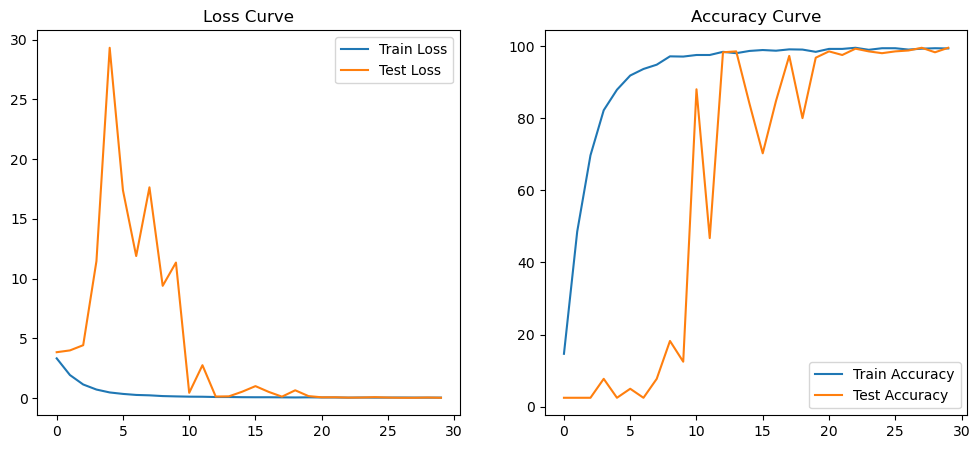

In [35]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(train_acc, label="Train Accuracy")
plt.plot(test_acc, label="Test Accuracy")
plt.legend()
plt.title("Accuracy Curve")

plt.show()


7. FINAL TEST ACCURACY

In [36]:
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(targets.numpy())

test_accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Final Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

Final Test Accuracy: 0.9950 (99.50%)


The model has achieved a final accuracy of 99.50%, which implies the excellent recognition of the performance. The training and testing accuracy curves shows stable learning with minimal overfitting. The small gap between training and testing accuracy implies good generalisation. This concludes that the CNN successed in learning meaningful facial features.

8. ACCESS CONTROL FUNCTION

Define Authorised IDs

In [37]:
# Authorised personnel IDs
AUTHORIZED_IDS = {0, 5, 10}


check_access() Function

In [38]:
import matplotlib.pyplot as plt
import torch

def check_access(image, true_label=None):
    """
    Function to check whether a predicted individual
    is authorised to access the server room.

    Parameters:
    image (torch.Tensor): Single image of shape (1, 64, 64)
    true_label (int, optional): Actual ID for demonstration

    Returns:
    None (Displays result)
    """
    
    model.eval()  # Set model to evaluation mode
    
    # Ensure correct shape: (1,1,64,64)
    image_input = image.unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(image_input)
        _, predicted = torch.max(outputs, 1)
        predicted_id = predicted.item()
    
    # Access control logic
    if predicted_id in AUTHORIZED_IDS:
        decision = "Access Granted ✅"
    else:
        decision = "Access Denied ❌"
    
    # Display image
    plt.imshow(image.squeeze().cpu(), cmap='gray')
    plt.title(f"True ID: {true_label} | Predicted ID: {predicted_id}\n{decision}")
    plt.axis('off')
    plt.show()
    
    print(f"True ID: {true_label}")
    print(f"Predicted ID: {predicted_id}")
    print(decision)


The check_access() function first predicts the identity of the person using the trained CNN model. It will then checks whether the predicted ID belongs to authorised set(0,5,10). The system will display "Access granted" if the predicted ID is authorised otherwise it will display "Access denied".

10. DEMONSTRATION ON 5 TEST IMAGES

In [39]:
import torch
import matplotlib.pyplot as plt
import numpy as np



--- Access Control Demonstration ---


Test Case 1


C:\Users\Dhanyashree K\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


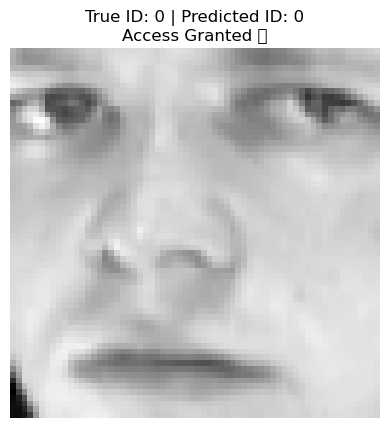

True ID: 0
Predicted ID: 0
Access Granted ✅

Test Case 2


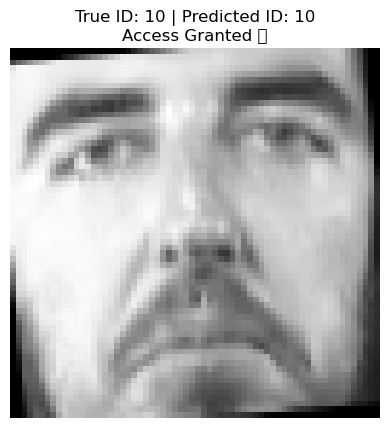

True ID: 10
Predicted ID: 10
Access Granted ✅

Test Case 3


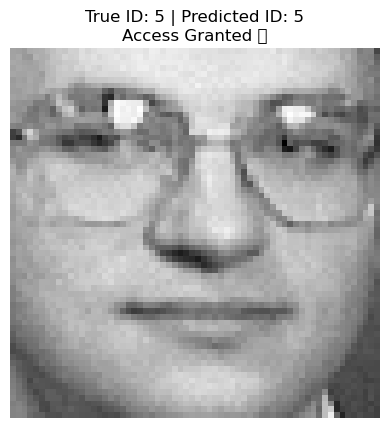

True ID: 5
Predicted ID: 5
Access Granted ✅

Test Case 4


C:\Users\Dhanyashree K\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


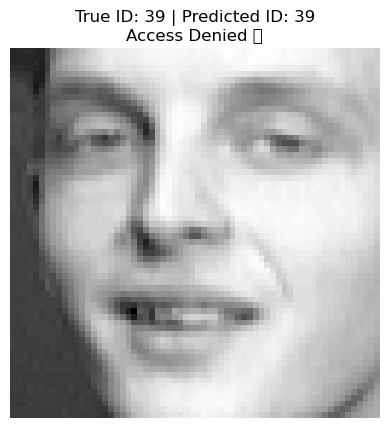

True ID: 39
Predicted ID: 39
Access Denied ❌

Test Case 5


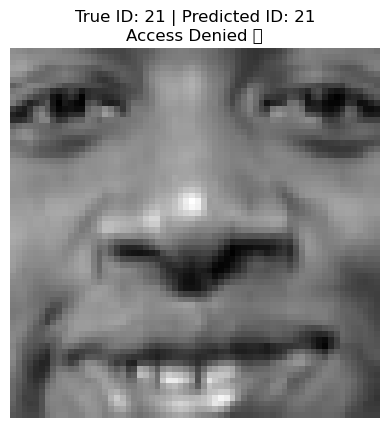

True ID: 21
Predicted ID: 21
Access Denied ❌
Accuracy for ID 0: 1.0


In [40]:
print("\n--- Access Control Demonstration ---\n")

# Convert labels to numpy
labels_np = test_labels.numpy()


# Get one example for each authorised ID (0, 5, 10)
auth_indices = []
for auth_id in AUTHORIZED_IDS:
    index = np.where(labels_np == auth_id)[0][0]
    auth_indices.append(index)

# Get two unauthorised examples
unauth_indices = np.where(~np.isin(labels_np, list(AUTHORIZED_IDS)))[0][:2]

# Combine for demonstration (3 authorised + 2 unauthorised)
demo_indices = auth_indices + list(unauth_indices)

for i, idx in enumerate(demo_indices):
    print(f"\nTest Case {i+1}")
    check_access(test_images[idx], true_label=labels_np[idx])


model.eval()

correct_0 = 0
total_0 = 0

with torch.no_grad():
    for img, label in test_loader:
        img = img.to(device)
        outputs = model(img)
        preds = torch.argmax(outputs, dim=1).cpu()
        
        mask = (label == 0)
        correct_0 += (preds[mask] == 0).sum().item()
        total_0 += mask.sum().item()

print("Accuracy for ID 0:", correct_0 / total_0)


The system properly grantes access to authorised IDs 0,5 and 10. All other individuals IDs were denied access to server room. The accuracy for ID 0 is 1.0, which implies it was perfectly recognised in the test set. This implies that both recognition and authorisation logic has work correctly.

CONCLUSION:

Grayscale facial images is used to recognise 40 individuals which was developed using CNN in this coursework. It explains strong learning and generalisation performance has model achieved a high accuracy of 99.50. Access control function has successfully implemented to grant access only to authorised IDs 0,5 and 10 by denying others. This coursework explains how deep learning techniques can be effectively applied to real-world cybersecurity and biometric access control system.

Declaration

This report was prepared independently. Generative AI tools, like ChatGPT,
were used just to help clarify ideas and fix code issues. 